In [180]:
import stim

from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations
from spiderstate.fault_tolerance_verification import verify_ftsp_ilp

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
code = "17_1_5"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X"
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print("Circuit output omitted to avoid terminal spam. You can export or print `final_circ`.")

Loading QECC: 17_1_5
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100)...
Computing initial single faults...

Running verification stabilizers search for t=2 layers (top_n=50, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 22.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 22.0
Injected 17 Z faults into Z-verification pool.

--- Z Faults Verification (FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 18.0
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 18.0

Synthesizing X fault verification circuits...

Synthesizing Z fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 23
Num CX: 61
Total instructions: 71
Circuit output omitted to avoid terminal spam. You can export or print `final

Num CX: 61


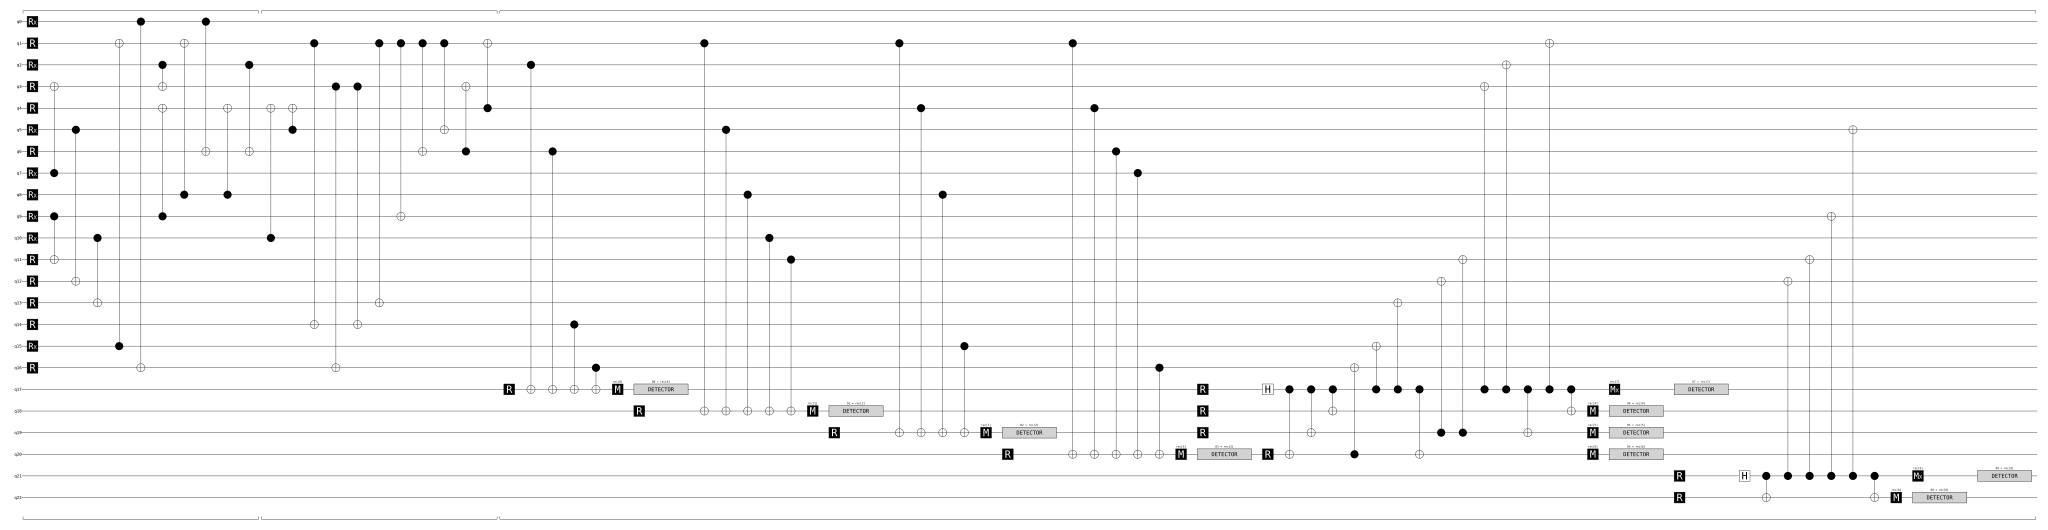

In [188]:
print(f"Num CX: {count_operations(final_circ)[0]}")

final_circ.diagram('timeline-svg')

In [189]:
final_circ.num_qubits

23

In [190]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_x.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0]]


In [191]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp_ilp(final_circ, H_z, np.atleast_2d(L_z), d, d // 2, verbose=True)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

Starting Exact ILP Verification for Z-basis (d=5, t=2).
    [PASS] UNSAT. The state preparation is strictly Fault-Tolerant.
Verification Result: True


In [140]:
print(final_circ)

RX 0
R 1
RX 2
R 3 4
RX 5
R 6
RX 7 8 9 10
R 11 12 13 14
RX 15
R 16
CX 7 3 9 11 5 12 10 13 15 1 0 16 2 3 9 4 8 1 0 6 8 4 2 6
TICK
CX 10 4 5 4 1 14 3 16 3 14 1 13 1 9 1 6 1 5 6 3 4 1
TICK
R 17
CX 2 17 6 17 14 17 16 17
M 17
DETECTOR rec[-1]
R 18
CX 1 18 5 18 8 18 10 18 11 18
M 18
DETECTOR rec[-1]
R 19
CX 1 19 4 19 8 19 15 19
M 19
DETECTOR rec[-1]
R 20
CX 1 20 4 20 6 20 7 20 16 20
M 20
DETECTOR rec[-1]
R 17 18 19 20
H 17
CX 17 20 17 19 17 18 20 16 17 15 17 13 17 20 19 12 19 11 17 3 17 2 17 19 17 1 17 18
M 18 19 20
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
MX 17
DETECTOR rec[-1]
R 21 22
H 21
CX 21 22 21 12 21 11 21 9 21 5 21 22
M 22
DETECTOR rec[-1]
MX 21
DETECTOR rec[-1]


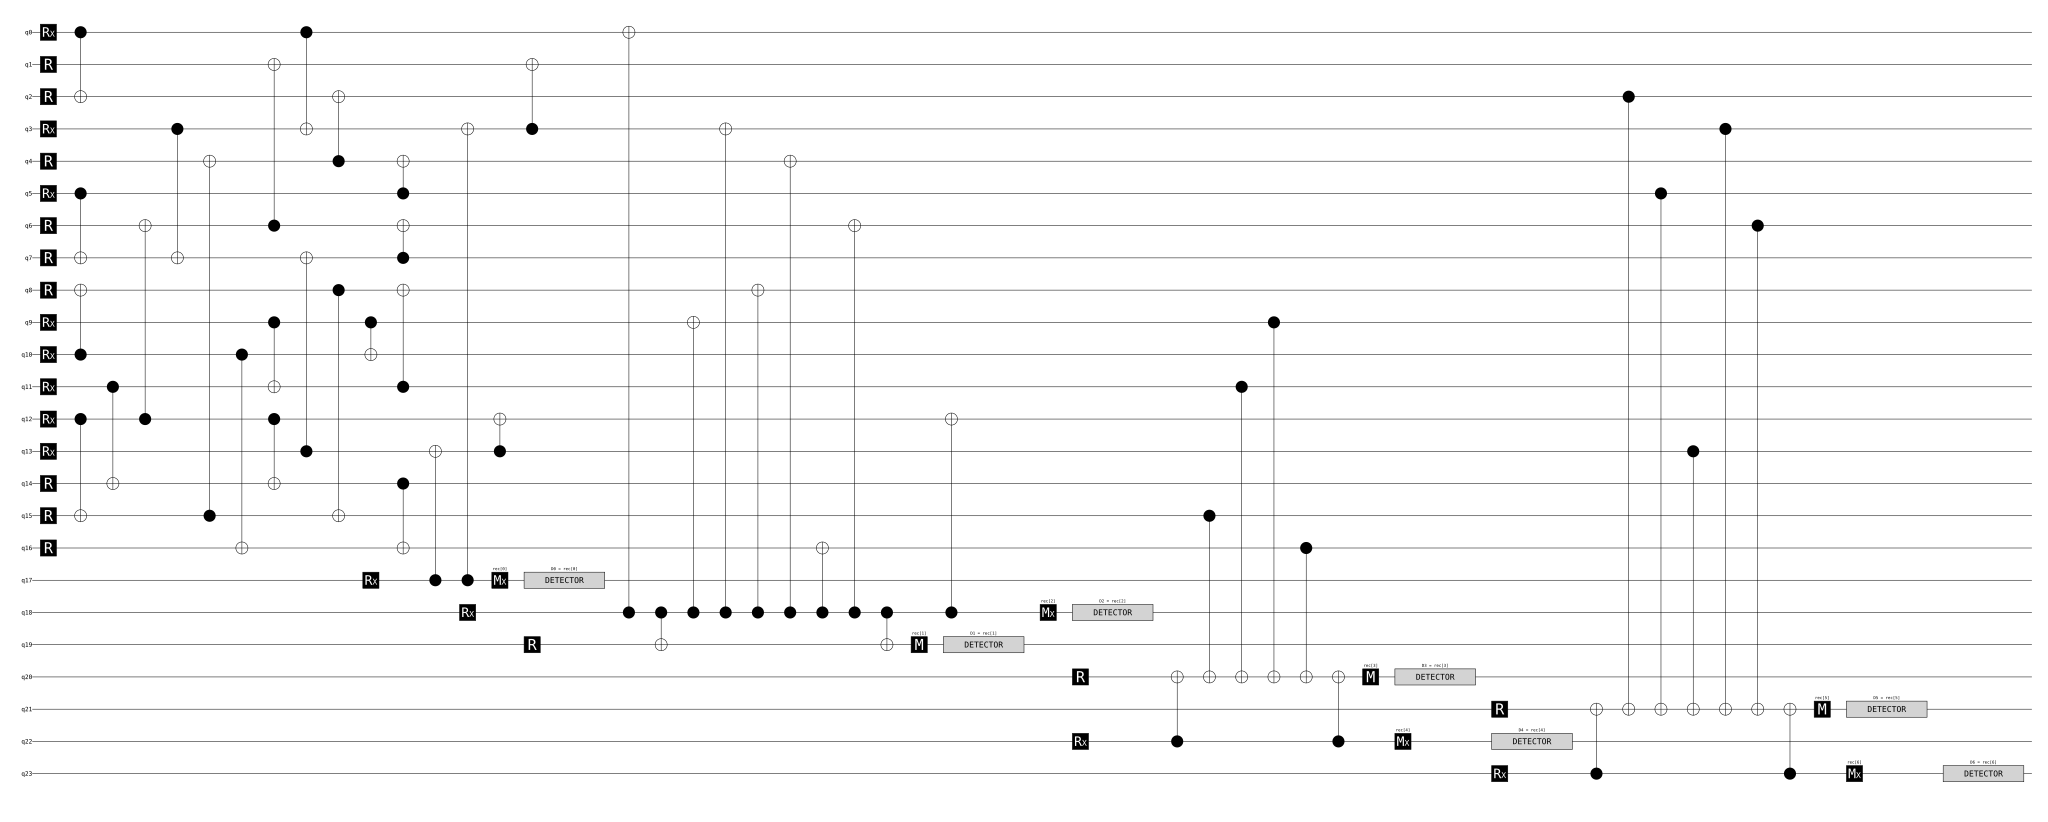

In [167]:
bens_circ = stim.Circuit("""
RX 0
R 1
R 2
RX 3
R 4
RX 5
R 6
R 7
R 8
RX 9
RX 10
RX 11
RX 12
RX 13
R 14
R 15
R 16
CX 12 15
CX 5 7
CX 10 8
CX 0 2
CX 11 14
CX 12 6
CX 3 7
CX 15 4
CX 10 16
CX 9 11
CX 12 14
CX 6 1
CX 13 7
CX 0 3
CX 8 15
CX 4 2
CX 9 10
RX 17
CX 11 8
CX 5 4
CX 14 16
CX 7 6
CX 17 13
CX 17 3
RX 18
CX 13 12
MX 17
DETECTOR rec[-1]
CX 3 1
R 19
CX 18 0
CX 18 19
CX 18 9
CX 18 3
CX 18 8
CX 18 4
CX 18 16
CX 18 6
CX 18 19
M 19
DETECTOR rec[-1]
CX 18 12
MX 18
DETECTOR rec[-1]
R 20
RX 22
CX 22 20
CX 15 20
CX 11 20
CX 9 20
CX 16 20
CX 22 20
M 20
DETECTOR rec[-1]
MX 22
DETECTOR rec[-1]
R 21
RX 23
CX 23 21
CX 2 21
CX 5 21
CX 13 21
CX 3 21
CX 6 21
CX 23 21
M 21
DETECTOR rec[-1]
MX 23
DETECTOR rec[-1]
""")
bens_circ.diagram("timeline-svg")

In [168]:
x_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1]
])

z_stabs_17_1_5 = np.array([
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
])

z_logs_17_1_5 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ z_stabs_17_1_5.T % 2)
print(meas_samples @ z_logs_17_1_5.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
[0 0 0 0 0 0 0 0 0 0]


In [181]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp_ilp(bens_circ, z_stabs_17_1_5, np.atleast_2d(z_logs_17_1_5), 5, 2, verbose=True)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

Starting Exact ILP Verification for Z-basis (d=5, t=2).
    [FAIL] Catastrophic cascade found!
    W(E_init)=2 faults bypassed flags to require only W(E_data)=2 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


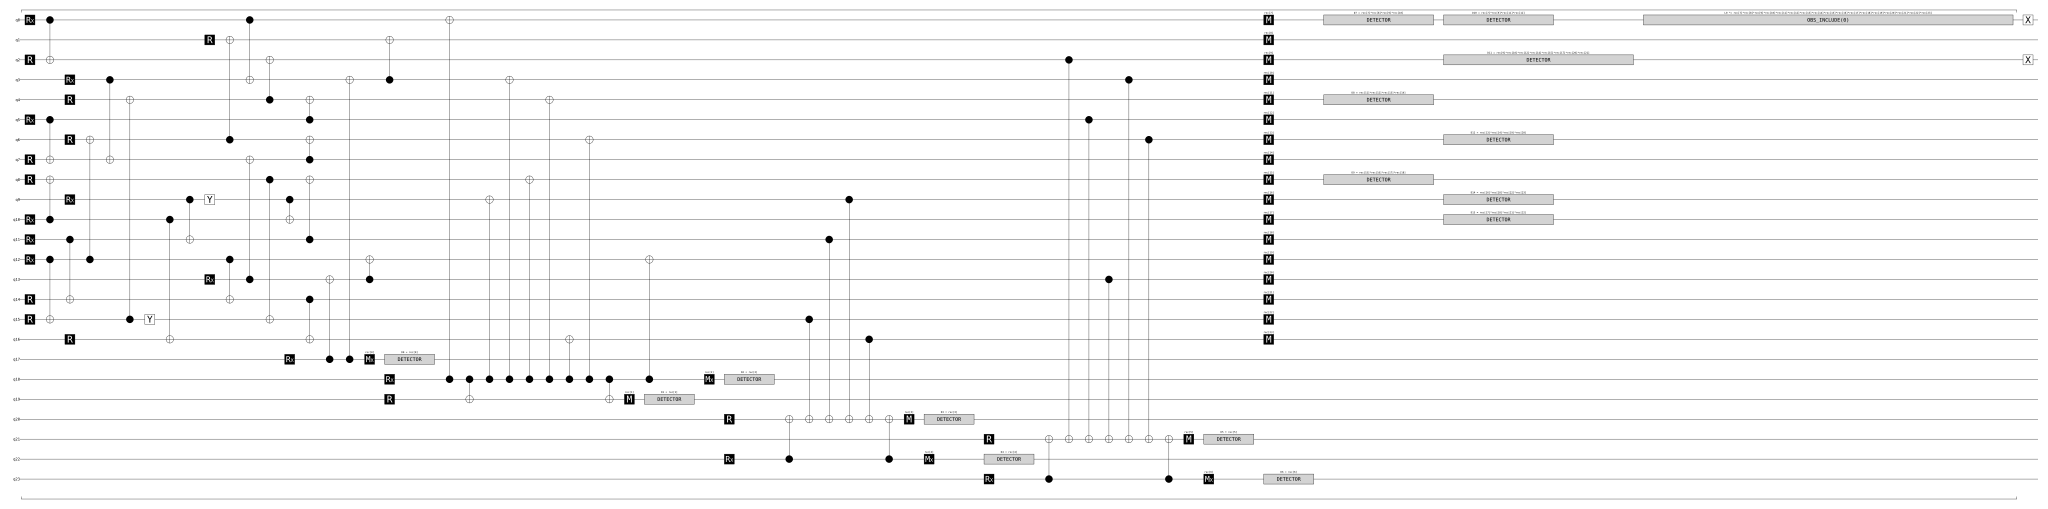

In [179]:
res_exhaustive.diagram('timeline-svg')

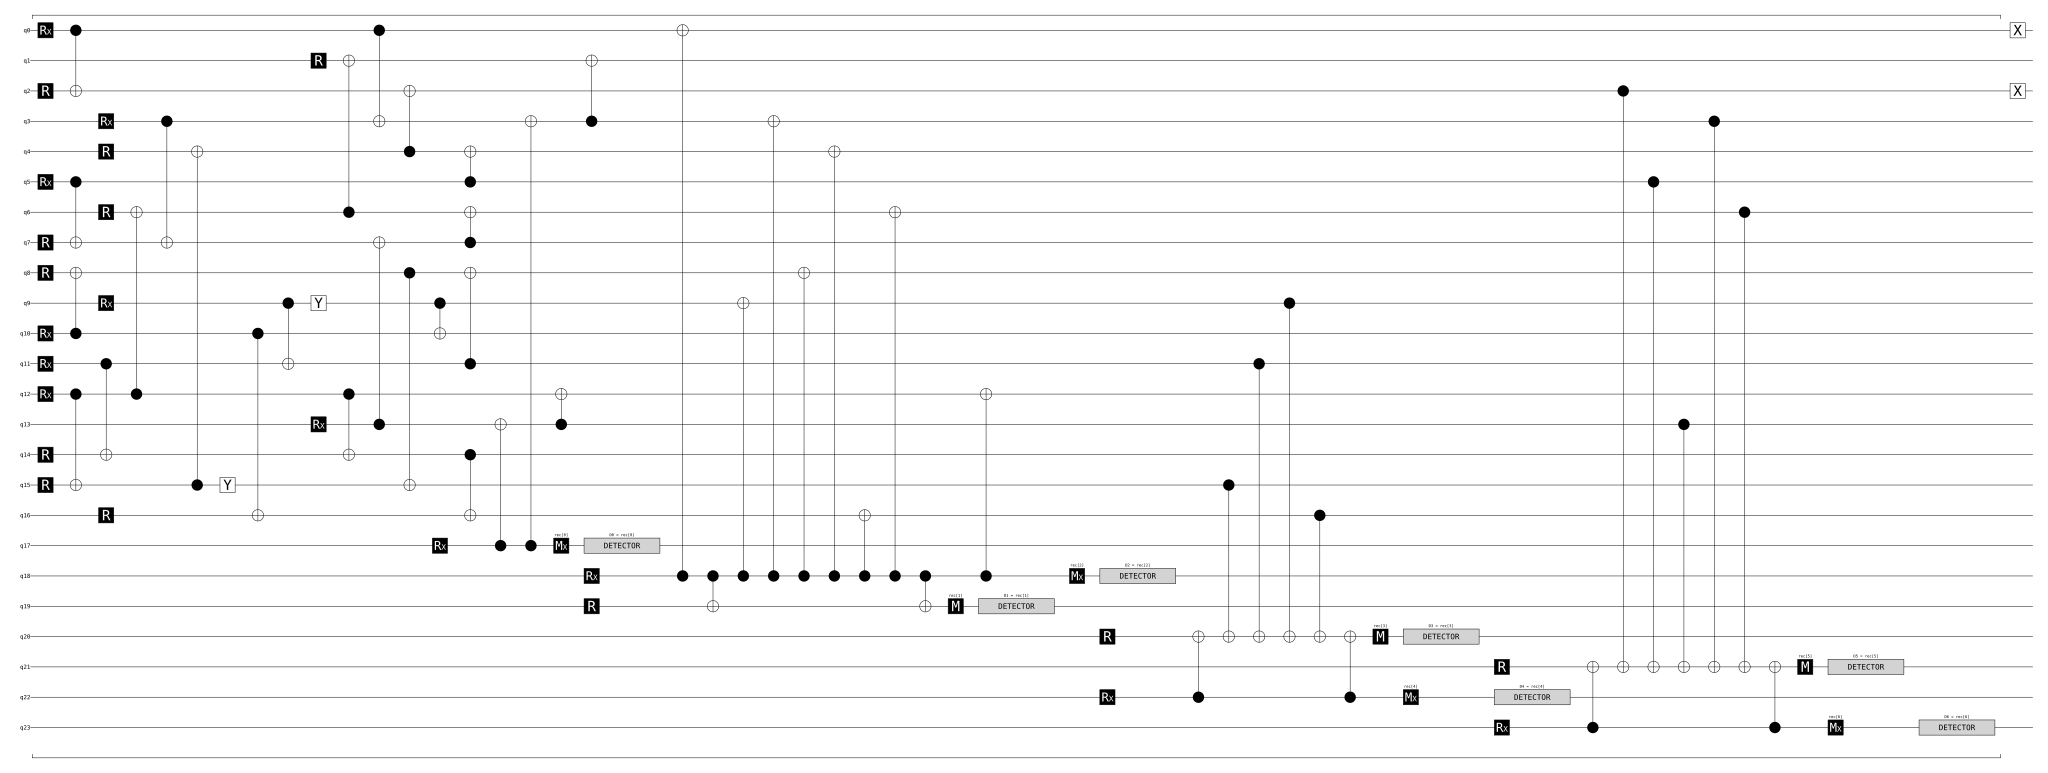

In [184]:
stim.Circuit('''
    RX 0
    R 2
    RX 5
    R 7 8
    RX 10 11 12
    R 14 15
    CX 12 15 5 7 10 8 0 2 11 14
    RX 3
    R 4 6
    RX 9
    R 16
    CX 12 6 3 7 15 4
    Y 15
    CX 10 16 9 11
    Y 9
    R 1
    RX 13
    CX 12 14 6 1 13 7 0 3 8 15 4 2 9 10
    RX 17
    CX 11 8 5 4 14 16 7 6 17 13 17 3 13 12
    MX 17
    DETECTOR rec[-1]
    RX 18
    CX 3 1
    R 19
    CX 18 0 18 19 18 9 18 3 18 8 18 4 18 16 18 6 18 19
    M 19
    DETECTOR rec[-1]
    CX 18 12
    MX 18
    DETECTOR rec[-1]
    R 20
    RX 22
    CX 22 20 15 20 11 20 9 20 16 20 22 20
    M 20
    DETECTOR rec[-1]
    MX 22
    DETECTOR rec[-1]
    R 21
    RX 23
    CX 23 21 2 21 5 21 13 21 3 21 6 21 23 21
    M 21
    DETECTOR rec[-1]
    MX 23
    DETECTOR rec[-1]
    TICK
    X 0 2
''').diagram('timeline-svg')